# ARTI 404 – Image Processing
## Lab 4 – Intensity Transformations and Filtering: Spatial Domain
### Assessment Tasks

**Course:** ARTI404 – Image Processing  
**Department:** Computer Engineering  
**College:** College of Computer Science and Information Technology  

---
## Import Libraries

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

---
## Task #1: Contrast Stretching (3rd – 80th Percentiles)

**Objective:** Using the moon image, rescale intensity values to include all intensities that fall within the **3rd and 80th percentiles**, and plot the histogram before and after.

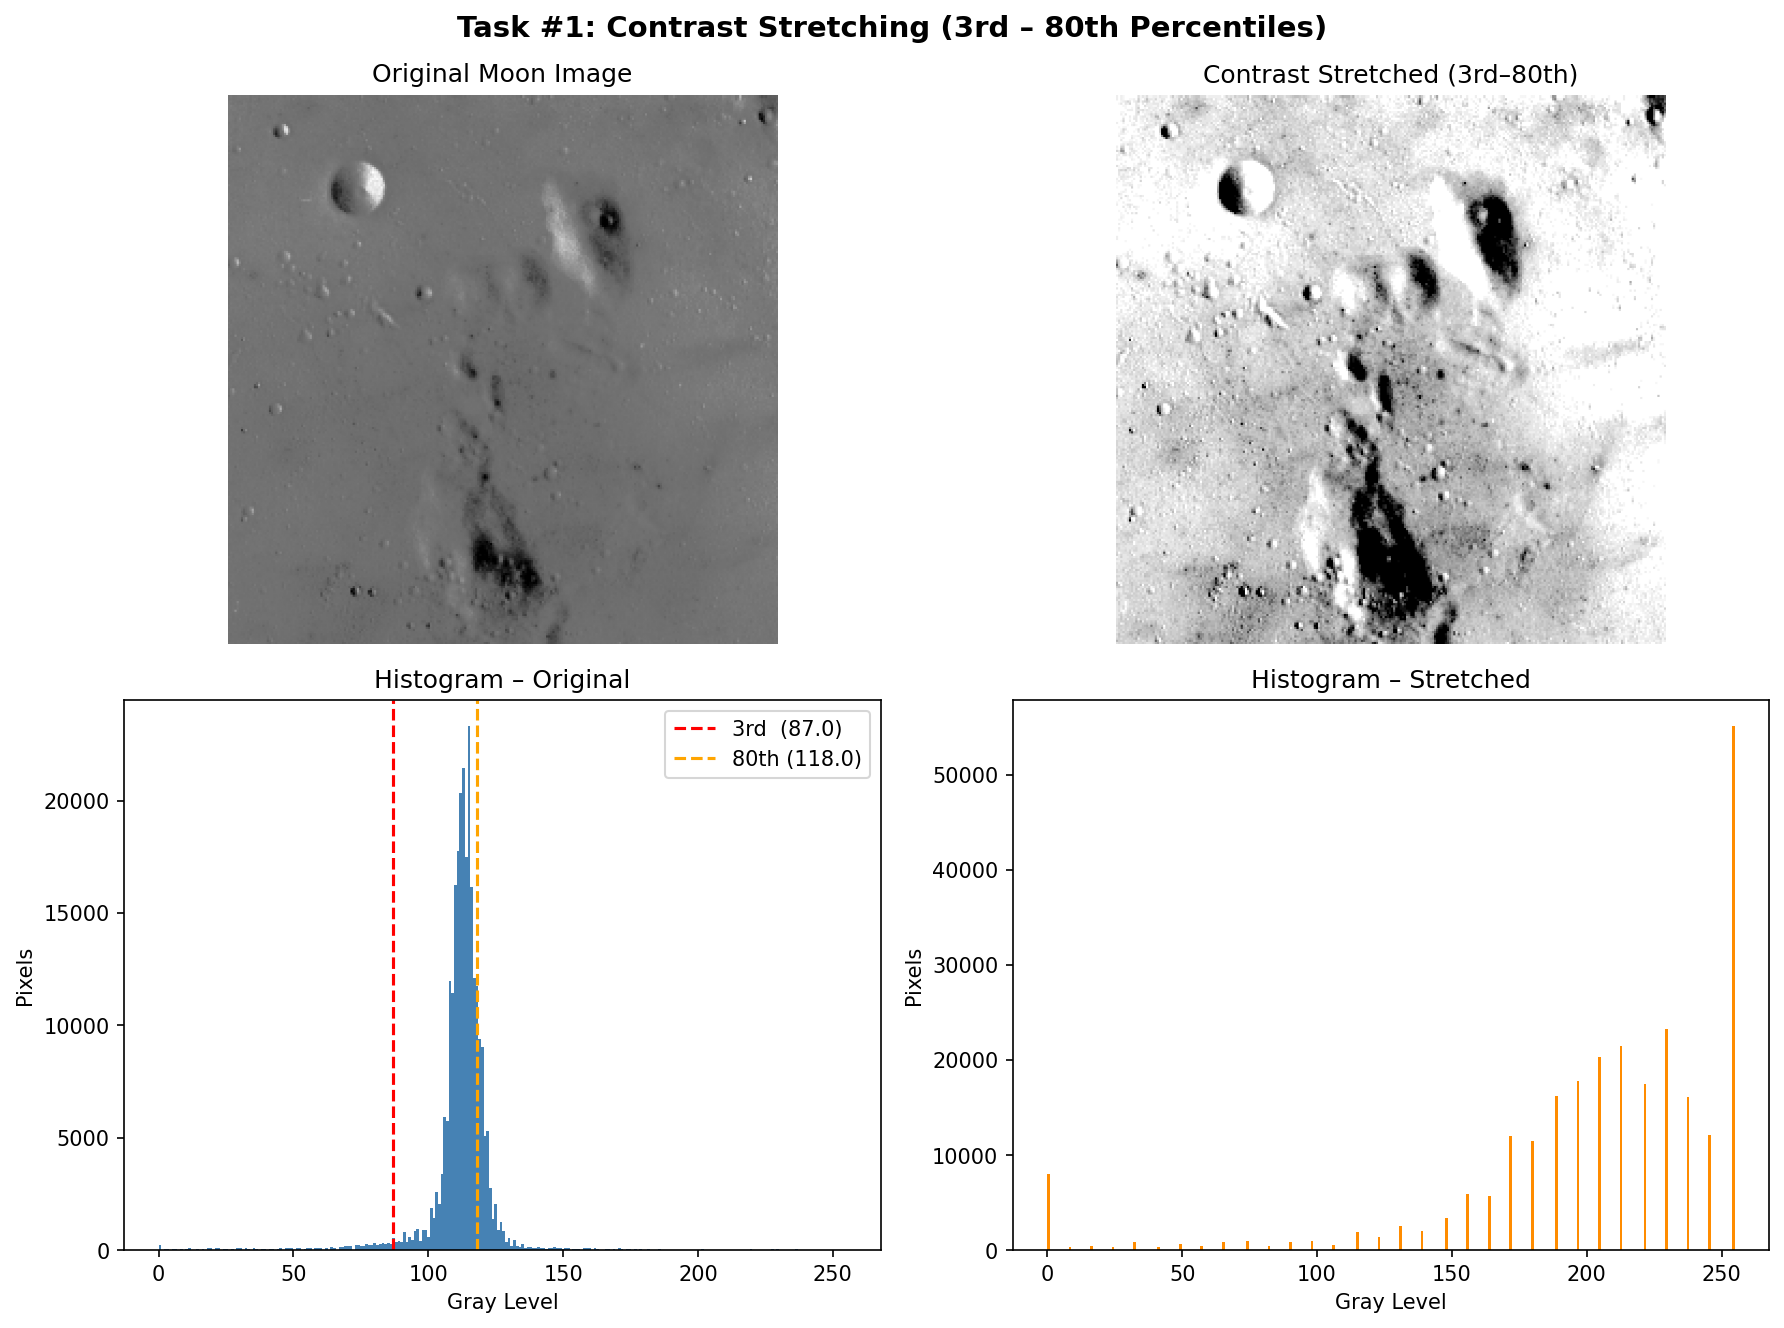

In [1]:
# Load the moon image
img = data.moon()

# Compute the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))
print(f"3rd percentile intensity: {p3:.2f}")
print(f"80th percentile intensity: {p80:.2f}")

# Rescale intensity values to the range [p3, p80]
img_rescale_task1 = exposure.rescale_intensity(img, in_range=(p3, p80))

# ---- Plot Original vs Contrast-Stretched ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Task #1: Contrast Stretching (3rd – 80th Percentiles)', fontsize=14, fontweight='bold')

# Original image
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Moon Image')
axes[0, 0].axis('off')

# Original histogram
axes[1, 0].hist(img.ravel(), bins=256, range=(0, 255), color='steelblue', edgecolor='none')
axes[1, 0].set_title('Histogram – Original')
axes[1, 0].set_xlabel('Gray Level Values')
axes[1, 0].set_ylabel('Number of Pixels')
axes[1, 0].axvline(p3,  color='red',    linestyle='--', label=f'3rd percentile ({p3:.1f})')
axes[1, 0].axvline(p80, color='orange', linestyle='--', label=f'80th percentile ({p80:.1f})')
axes[1, 0].legend()

# Rescaled image
axes[0, 1].imshow(img_rescale_task1, cmap='gray')
axes[0, 1].set_title('Contrast Stretched (3rd–80th Percentile)')
axes[0, 1].axis('off')

# Rescaled histogram
axes[1, 1].hist(img_rescale_task1.ravel(), bins=256, range=(0, 255), color='darkorange', edgecolor='none')
axes[1, 1].set_title('Histogram – Contrast Stretched')
axes[1, 1].set_xlabel('Gray Level Values')
axes[1, 1].set_ylabel('Number of Pixels')

plt.tight_layout()
plt.savefig('task1_contrast_stretch.png', dpi=150, bbox_inches='tight')
plt.show()
print("Task #1 complete – figure saved as task1_contrast_stretch.png")

**Observation:**  
By stretching only the intensity range between the 3rd and 80th percentiles, pixels below the 3rd percentile are clipped to 0 (black) and pixels above the 80th percentile are clipped to 255 (white). This aggressively brightens the mid-range intensities, increasing contrast in the central tonal region of the moon image while saturating the very dark and very bright areas.

---
## Task #2: Histogram Equalization

**Objective:** Using the moon image and `exposure.equalize_hist`, display the image and histogram after flattening (equalizing) the histogram.

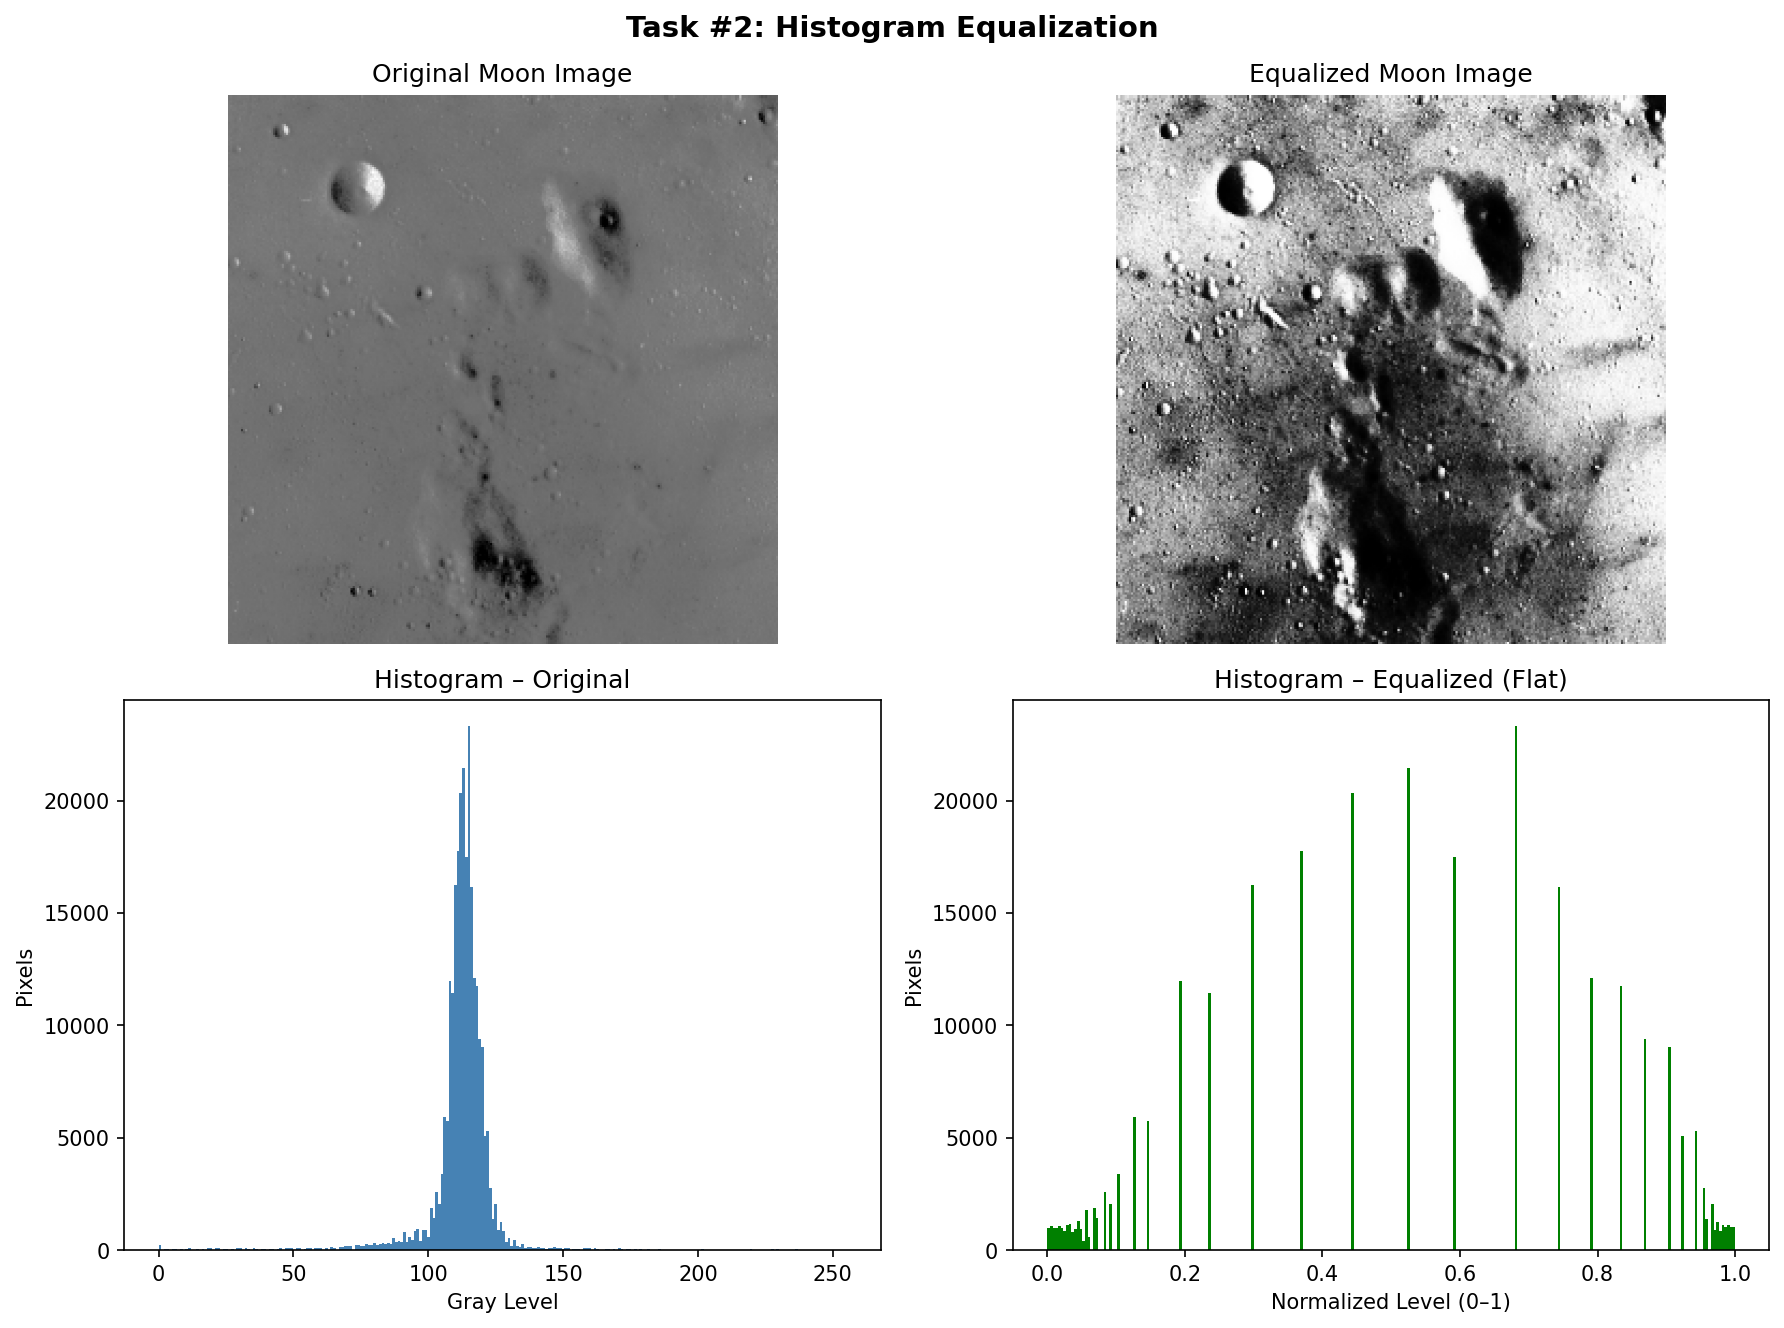

In [2]:
# Load the moon image
img = data.moon()

# Apply histogram equalization
img_eq = exposure.equalize_hist(img)

# ---- Plot Original vs Equalized ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Task #2: Histogram Equalization', fontsize=14, fontweight='bold')

# Original image
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Moon Image')
axes[0, 0].axis('off')

# Original histogram
axes[1, 0].hist(img.ravel(), bins=256, range=(0, 255), color='steelblue', edgecolor='none')
axes[1, 0].set_title('Histogram – Original')
axes[1, 0].set_xlabel('Gray Level Values')
axes[1, 0].set_ylabel('Number of Pixels')

# Equalized image  (equalize_hist returns float [0,1])
axes[0, 1].imshow(img_eq, cmap='gray')
axes[0, 1].set_title('Histogram Equalized Moon Image')
axes[0, 1].axis('off')

# Equalized histogram (values are in [0,1] range)
axes[1, 1].hist(img_eq.ravel(), bins=256, range=(0, 1), color='green', edgecolor='none')
axes[1, 1].set_title('Histogram – Equalized (Flattened)')
axes[1, 1].set_xlabel('Normalized Gray Level (0–1)')
axes[1, 1].set_ylabel('Number of Pixels')

plt.tight_layout()
plt.savefig('task2_histogram_equalization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Task #2 complete – figure saved as task2_histogram_equalization.png")

**Observation:**  
Histogram equalization redistributes intensity values so that the resulting histogram is approximately uniform (flat) across the entire gray-scale range. This enhances global contrast—details in both dark and bright regions of the moon become more visible. The output image from `equalize_hist` is returned as a float array in the range [0, 1].

---
## Task #3: Histogram Matching

**Objective:** Use the **rocket image** as the reference and the **chelsea image** as the source (both from `skimage.data`) and implement histogram matching.

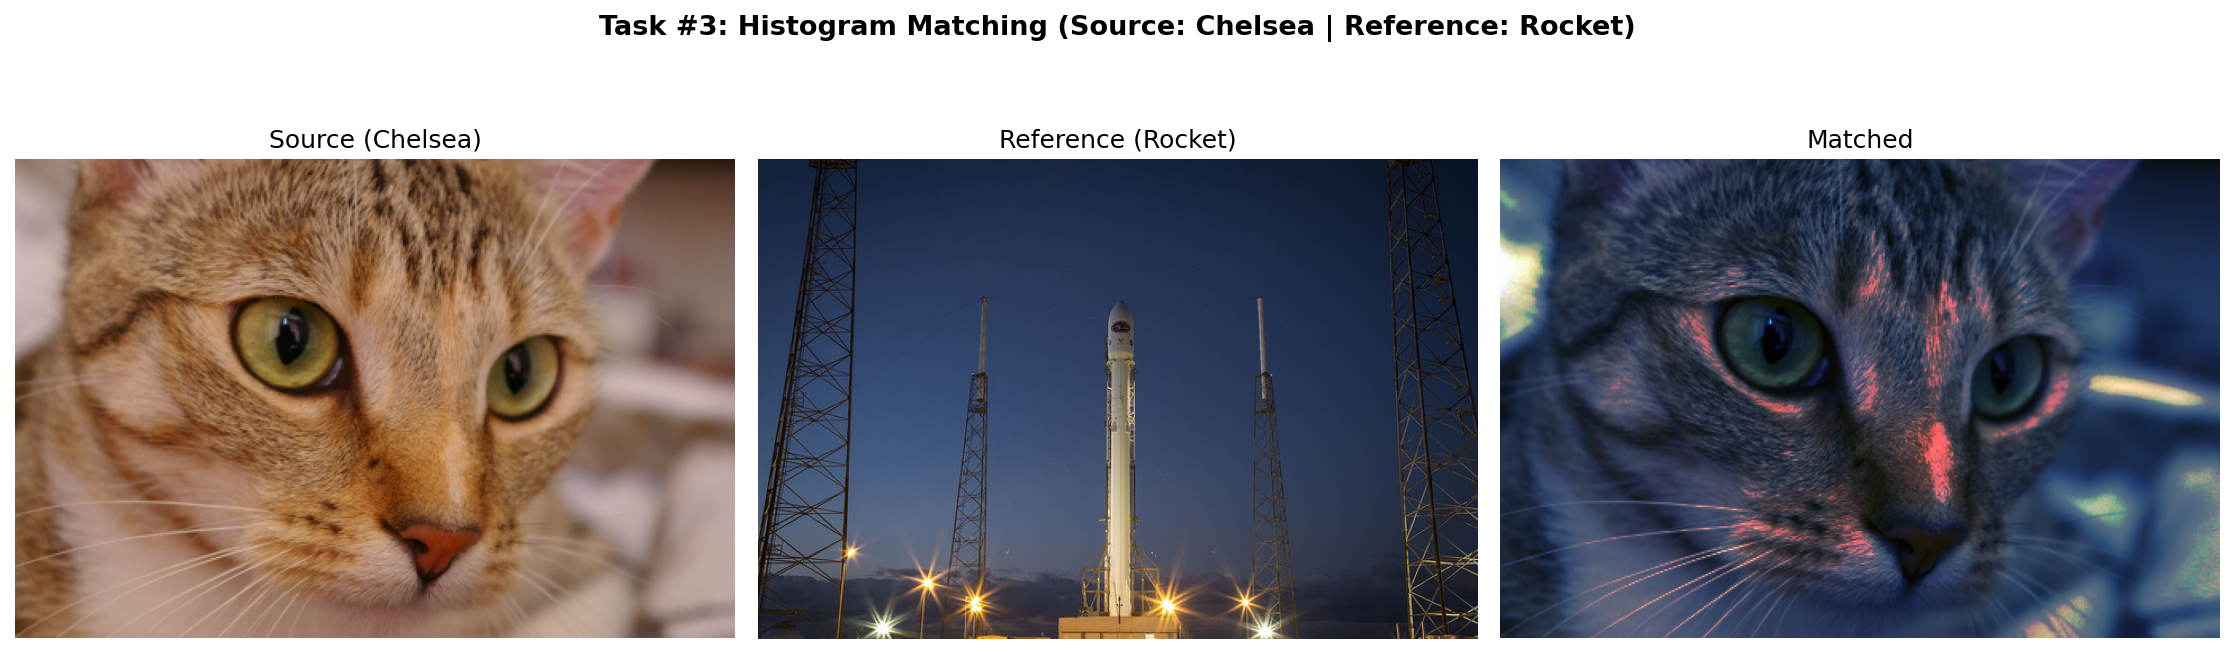

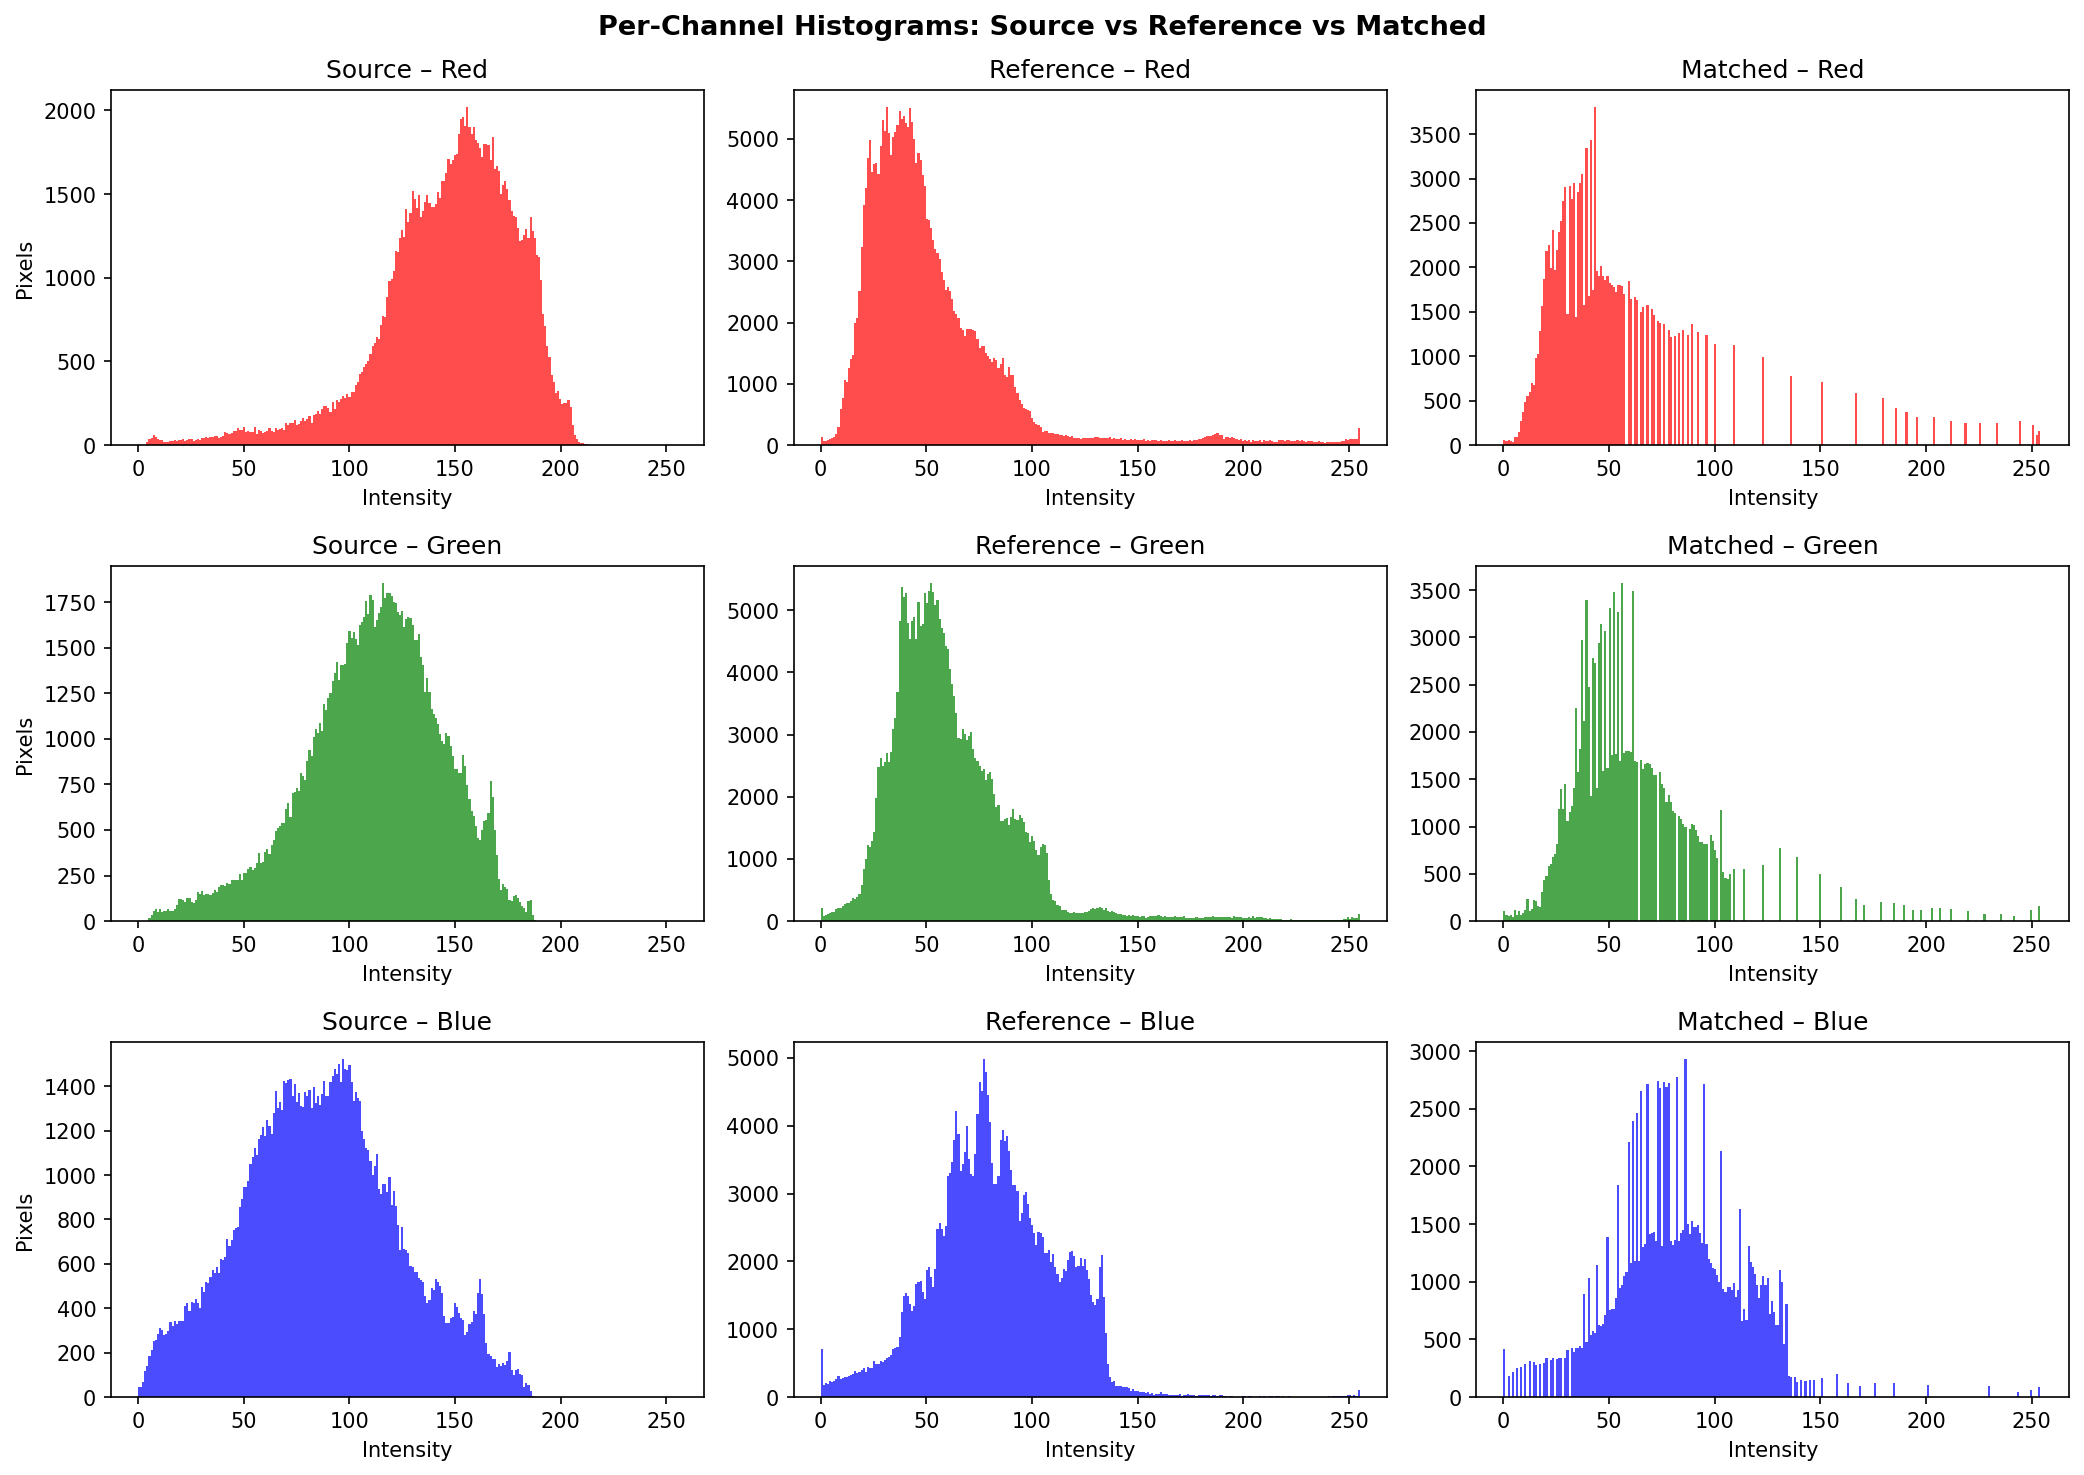

In [3]:
from skimage.exposure import match_histograms

# Load source and reference images
source    = data.chelsea()   # RGB image of a cat
reference = data.rocket()    # RGB image of a rocket

print(f"Source  (chelsea) shape : {source.shape}")
print(f"Reference (rocket) shape: {reference.shape}")

# Perform histogram matching
# channel_axis=2 tells the function to match each colour channel independently
matched = match_histograms(source, reference, channel_axis=2)

# ---- Visualise images ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Task #3: Histogram Matching\n(Source: Chelsea  |  Reference: Rocket)', fontsize=13, fontweight='bold')

axes[0].imshow(source)
axes[0].set_title('Source Image\n(Chelsea – cat)')
axes[0].axis('off')

axes[1].imshow(reference)
axes[1].set_title('Reference Image\n(Rocket)')
axes[1].axis('off')

axes[2].imshow(matched.astype(np.uint8))
axes[2].set_title('Matched Image\n(Chelsea with Rocket histogram)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('task3_histogram_matching_images.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Visualise per-channel histograms ----
channels = ['Red', 'Green', 'Blue']
colors   = ['red', 'green', 'blue']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Per-Channel Histograms: Source vs Reference vs Matched', fontsize=13, fontweight='bold')

for ch, (channel_name, color) in enumerate(zip(channels, colors)):
    # Source channel histogram
    axes[ch, 0].hist(source[:, :, ch].ravel(), bins=256, range=(0, 255), color=color, alpha=0.7)
    axes[ch, 0].set_title(f'Source – {channel_name} Channel')
    axes[ch, 0].set_ylabel('Pixel Count')
    axes[ch, 0].set_xlabel('Intensity')

    # Reference channel histogram
    axes[ch, 1].hist(reference[:, :, ch].ravel(), bins=256, range=(0, 255), color=color, alpha=0.7)
    axes[ch, 1].set_title(f'Reference – {channel_name} Channel')
    axes[ch, 1].set_xlabel('Intensity')

    # Matched channel histogram
    axes[ch, 2].hist(matched[:, :, ch].ravel(), bins=256, range=(0, 255), color=color, alpha=0.7)
    axes[ch, 2].set_title(f'Matched – {channel_name} Channel')
    axes[ch, 2].set_xlabel('Intensity')

plt.tight_layout()
plt.savefig('task3_histogram_matching_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Task #3 complete – figures saved.")

**Observation:**  
Histogram matching (also called histogram specification) transforms the tone distribution of the source image (chelsea – a brightly lit cat) so that it closely resembles the tone distribution of the reference image (rocket – a darker, more blue-shifted scene). After matching:
- The per-channel histograms of the *matched* image closely mirror those of the *reference* image.
- The visual appearance of the chelsea image shifts towards the cooler, darker colour palette of the rocket image.
- This technique is commonly used for colour/exposure harmonisation between images taken under different lighting conditions.